# SegTran Training and Inference — Optic Cup

This notebook trains SegTran with the REFUGE training set (960 preprocessed images)  
and runs inference on all other sets:

| Dataset         | Split   | Type          | #Images  |
|:--------------- |:------- |:------------- |:-------- |
| `refuge_train`  | train   | ID — Train    | 960      |
| `refuge_test`   | test    | ID — Test     | 240      |
| `origa`         | all     | OOD           | 650      |
| `g1020`         | all     | OOD           | 2040     |

**Prerequisite**: run `05_preprocessing_OpticCup_REFUGE.ipynb` first.

In [2]:
import os
import sys
import json
import subprocess
import glob
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# ─── Paths ─────────────────────────────────────────────────────────────────
BASE_DIR    = './'
SEGTRAN_DIR = os.path.join(BASE_DIR, 'segtran')
CODE_DIR    = os.path.join(SEGTRAN_DIR, 'code')
DATA_DIR    = os.path.join(SEGTRAN_DIR, 'data', 'fundus')
MODEL_DIR   = os.path.join(SEGTRAN_DIR, 'model')

os.makedirs(MODEL_DIR, exist_ok=True)

# Check that training data exists
for ds in ['refuge_train', 'refuge_test', 'origa', 'g1020']:
    img_dir = os.path.join(DATA_DIR, ds, 'images')
    n = len(os.listdir(img_dir)) if os.path.isdir(img_dir) else 0
    status = '✓' if n > 0 else '✗ EMPTY'
    print(f'  [{status}] {ds}: {n} images')

print(f'\nCode dir: {CODE_DIR}')

  [✓] refuge_train: 960 images
  [✓] refuge_test: 240 imagens
  [✓] origa: 650 imagens
  [✓] g1020: 1020 imagens

Code dir: ./segtran/code


## 1. SegTran training configuration

In [2]:
# ─── Execution control ─────────────────────────────────────────────────────
# Set True to skip training and use an existing checkpoint.
SKIP_TRAINING = True

# ─── SegTran parameters ────────────────────────────────────────────────────
TRAIN_ARGS = {
    '--task':         'fundus',
    '--ds':           'refuge_train',
    '--split':        'all',           # usa all.list (= train.list aqui)
    '--net':          'segtran',
    '--bb':           'eff-b4',        # EfficientNet-B4 backbone
    '--translayers':  '3',
    '--layercompress':'1,1,2,2',
    '--maxiter':      '10000',
    '--bs':           '6',
    '--gray':         '0.5',
    '--noqkbias':     '',              # flag (sem valor)
    '--saveiter':     '500',
    '--insize':       '576,576',   # crops are 576x576 → chosen_size must match
}

# Build command line
def build_cmd(script, args_dict, extra_flags=None):
    cmd = ['python3', script]
    for k, v in args_dict.items():
        cmd.append(k)
        if v != '':
            cmd.append(str(v))
    if extra_flags:
        cmd.extend(extra_flags)
    return cmd

train_cmd = build_cmd('train2d.py', TRAIN_ARGS)
print('Training command:')
print(' '.join(train_cmd))

Comando de treino:
python3 train2d.py --task fundus --ds refuge_train --split all --net segtran --bb eff-b4 --translayers 3 --layercompress 1,1,2,2 --maxiter 10000 --bs 6 --gray 0.5 --noqkbias --saveiter 500 --insize 576,576


## 2. SegTran training on REFUGE train

In [3]:
def run_segtran(cmd, cwd, log_prefix=''):
    """Execute a SegTran script and stream its output."""
    print(f'Running: {" ".join(cmd)}')
    print(f'Directory: {cwd}\n')

    proc = subprocess.Popen(
        cmd,
        cwd=cwd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1
    )

    lines = []
    for line in proc.stdout:
        line = line.rstrip()
        lines.append(line)
        # Exibe apenas linhas relevantes
        if any(kw in line.lower() for kw in
               ['iter', 'loss', 'dice', 'save', 'error', 'warning', 'epoch',
                'loaded', 'train', 'fundus', 'checkpoint']):
            print(f'{log_prefix}{line}')

    proc.wait()
    if proc.returncode != 0:
        print('\n[ERROR] Process exited with code:', proc.returncode)
        print('\n--- Last lines ---')
        for l in lines[-30:]:
            print(l)
    else:
        print(f'\n✓ Done (returncode=0)')

    return proc.returncode, lines


# Run training — skip by setting SKIP_TRAINING = True in the cell above
if SKIP_TRAINING:
    print('Training skipped (SKIP_TRAINING=True). Using existing checkpoint.')
    retcode, train_log = 0, []
else:
    retcode, train_log = run_segtran(train_cmd, cwd=CODE_DIR, log_prefix='[TRAIN] ')

Treinamento ignorado (SKIP_TRAINING=True). Usando checkpoint existente.


In [4]:
# Locate the trained checkpoint directory
import glob as _glob
import re as _re

cp_dirs = sorted(
    _glob.glob(os.path.join(MODEL_DIR, 'segtran-fundus-refuge_train-*')),
    key=os.path.getmtime
)

if not cp_dirs:
    raise FileNotFoundError(
        f'Nenhum checkpoint encontrado em {MODEL_DIR}. '
        'Check that training completed successfully.'
    )

# Absolute path — test2d.py runs from CODE_DIR, so relative paths would break
CHECKPOINT_DIR = os.path.abspath(cp_dirs[-1])
print(f'Checkpoint dir: {CHECKPOINT_DIR}')

# List available checkpoints (numerically ordered by iteration number)
ckpts = sorted(
    _glob.glob(os.path.join(CHECKPOINT_DIR, 'iter_*.pth')),
    key=lambda p: int(_re.search(r'iter_(\d+)', p).group(1))
)
print(f'Checkpoints ({len(ckpts)}):')
for c in ckpts[-5:]:
    print(f'  {os.path.basename(c)}')

# Derive EVAL_ITERS directly from existing files on disk
EVAL_ITERS = ','.join(
    _re.search(r'iter_(\d+)', os.path.basename(c)).group(1)
    for c in ckpts
)
print(f'\nIterations for evaluation: {EVAL_ITERS}')


Checkpoint dir: /home/bruno-borges/soft_dice_confidence/tasks_models/optic_cup/segtran/model/segtran-fundus-refuge_train-05201451
Checkpoints (20):
  iter_8000.pth
  iter_8500.pth
  iter_9000.pth
  iter_9500.pth
  iter_10000.pth

Iterations for evaluation: 500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000


## 3. Inference — REFUGE test (ID)

In [3]:
# ─── Inference helpers (run this cell before any inference) ───
PRED_ROOT = os.path.join(SEGTRAN_DIR, 'prediction')
os.makedirs(PRED_ROOT, exist_ok=True)

def inference_args(ds_name, split, checkpoint_dir, iters):
    """Builds argument dictionary for test2d.py."""
    return {
        '--task':         'fundus',
        '--ds':           ds_name,
        '--split':        split,
        '--net':          'segtran',
        '--bb':           'eff-b4',
        '--translayers':  '3',
        '--layercompress':'1,1,2,2',
        '--noqkbias':     '',     # flag booleana (sem valor)
        '--gray':         '0.5',
        '--cpdir':        checkpoint_dir,
        '--iters':        iters,
        '--bs':           '4',
        '--insize':       '576,576',   # crops are 576x576
        '--verbose':      '',     # exibe scores individuais
    }


In [12]:
# REFUGE test (ID)
test_args = inference_args(
    ds_name='refuge_test',
    split='all',
    checkpoint_dir=CHECKPOINT_DIR,
    iters=EVAL_ITERS,
)
test_cmd = build_cmd('test2d.py', test_args)
print('Test command (REFUGE test):')
print(' '.join(test_cmd))

retcode_test, test_log = run_segtran(test_cmd, cwd=CODE_DIR, log_prefix='[TEST-ID] ')

Comando de teste (REFUGE test):
python3 test2d.py --task fundus --ds refuge_test --split all --net segtran --bb eff-b4 --translayers 3 --layercompress 1,1,2,2 --noqkbias --gray 0.5 --cpdir /home/bruno-borges/soft_dice_confidence/tasks_models/optic_cup/segtran/model/segtran-fundus-refuge_train-05201451 --iters 500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000 --bs 4 --insize 576,576 --verbose
Executando: python3 test2d.py --task fundus --ds refuge_test --split all --net segtran --bb eff-b4 --translayers 3 --layercompress 1,1,2,2 --noqkbias --gray 0.5 --cpdir /home/bruno-borges/soft_dice_confidence/tasks_models/optic_cup/segtran/model/segtran-fundus-refuge_train-05201451 --iters 500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000 --bs 4 --insize 576,576 --verbose
Directory: ./segtran/code

[TEST-ID] 'fundus' mean/std loaded from 'fundus-cropped-gray0.5-stats.json'
[TEST-ID] 'all' 240 samples

## 4. Inference — ORIGA (OOD)

In [13]:
origa_args = inference_args(
    ds_name='origa',
    split='all',
    checkpoint_dir=CHECKPOINT_DIR,
    iters=EVAL_ITERS,
)
origa_cmd = build_cmd('test2d.py', origa_args)
print('Inference command (ORIGA OOD):')
print(' '.join(origa_cmd))

retcode_origa, origa_log = run_segtran(origa_cmd, cwd=CODE_DIR, log_prefix='[OOD-ORIGA] ')


Inference command (ORIGA OOD):
python3 test2d.py --task fundus --ds origa --split all --net segtran --bb eff-b4 --translayers 3 --layercompress 1,1,2,2 --noqkbias --gray 0.5 --cpdir /home/bruno-borges/soft_dice_confidence/tasks_models/optic_cup/segtran/model/segtran-fundus-refuge_train-05201451 --iters 500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000 --bs 4 --insize 576,576 --verbose
Executando: python3 test2d.py --task fundus --ds origa --split all --net segtran --bb eff-b4 --translayers 3 --layercompress 1,1,2,2 --noqkbias --gray 0.5 --cpdir /home/bruno-borges/soft_dice_confidence/tasks_models/optic_cup/segtran/model/segtran-fundus-refuge_train-05201451 --iters 500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000 --bs 4 --insize 576,576 --verbose
Directory: ./segtran/code

[OOD-ORIGA] 'fundus' mean/std loaded from 'fundus-cropped-gray0.5-stats.json'
[OOD-ORIGA] 'all' 650 samples of size 

## 5. Inference — G1020 (OOD)

In [6]:
g1020_args = inference_args(
    ds_name='g1020',
    split='all',
    checkpoint_dir=CHECKPOINT_DIR,
    iters=EVAL_ITERS,
)
g1020_cmd = build_cmd('test2d.py', g1020_args)
print('Inference command (G1020 OOD):')
print(' '.join(g1020_cmd))

retcode_g1020, g1020_log = run_segtran(g1020_cmd, cwd=CODE_DIR, log_prefix='[OOD-G1020] ')


Inference command (G1020 OOD):
python3 test2d.py --task fundus --ds g1020 --split all --net segtran --bb eff-b4 --translayers 3 --layercompress 1,1,2,2 --noqkbias --gray 0.5 --cpdir /home/bruno-borges/soft_dice_confidence/tasks_models/optic_cup/segtran/model/segtran-fundus-refuge_train-05201451 --iters 500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000 --bs 4 --insize 576,576 --verbose
Executando: python3 test2d.py --task fundus --ds g1020 --split all --net segtran --bb eff-b4 --translayers 3 --layercompress 1,1,2,2 --noqkbias --gray 0.5 --cpdir /home/bruno-borges/soft_dice_confidence/tasks_models/optic_cup/segtran/model/segtran-fundus-refuge_train-05201451 --iters 500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000 --bs 4 --insize 576,576 --verbose
Directory: ./segtran/code

[OOD-G1020] 'fundus' mean/std loaded from 'fundus-cropped-gray0.5-stats.json'
[OOD-G1020] 'all' 1020 samples of size

## 6. Extracting metrics from logs

In [14]:
import re

def extract_dice(log_lines):
    """Extract Dice for disc and cup from test2d.py logs.

    O test2d.py imprime:
      class 1: dice = X.XXX   ← disc
      class 2: dice = X.XXX   ← cup
      Average dice: X.XXX
    """
    disc_dice = cup_dice = avg_dice = None

    for line in log_lines:
        # class 1: dice = 0.923
        m1 = re.search(r'class\s+1\s*:\s*dice\s*=\s*([0-9]+\.?[0-9]*)', line, re.IGNORECASE)
        if m1:
            disc_dice = float(m1.group(1))

        m2 = re.search(r'class\s+2\s*:\s*dice\s*=\s*([0-9]+\.?[0-9]*)', line, re.IGNORECASE)
        if m2:
            cup_dice = float(m2.group(1))

        # Average dice: 0.895
        ma = re.search(r'[Aa]verage\s+dice\s*:\s*([0-9]+\.?[0-9]*)', line)
        if ma:
            avg_dice = float(ma.group(1))

    if disc_dice is not None and cup_dice is not None:
        if avg_dice is None:
            avg_dice = (disc_dice + cup_dice) / 2
        return {'disc': disc_dice, 'cup': cup_dice, 'avg': avg_dice}
    return {}


print('=== Metrics extracted from logs ===\n')
for name, log in [('REFUGE test (ID)', test_log),
                  ('ORIGA (OOD)',       origa_log),
                  ('G1020 (OOD)',       g1020_log)]:
    m = extract_dice(log)
    if m:
        print(f'{name}:')
        print(f'  Disc Dice = {m["disc"]:.4f}')
        print(f'  Cup  Dice = {m["cup"]:.4f}')
        print(f'  Avg  Dice = {m["avg"]:.4f}\n')
    else:
        print(f'{name}: metrics not found in log.')
        print('  Last log lines:')
        for l in log[-15:]:
            if l.strip():
                print(f'    {l}')
        print()


=== Metrics extracted from logs ===

REFUGE test (ID):
  Disc Dice = 0.9630
  Cup  Dice = 0.8950
  Avg  Dice = 0.9290

ORIGA (OOD):
  Disc Dice = 0.9260
  Cup  Dice = 0.8570
  Avg  Dice = 0.8920

G1020 (OOD):
  Disc Dice = 0.6370
  Cup  Dice = 0.4850
  Avg  Dice = 0.5610



## 7. Prediction visualization


--- refuge_test ---


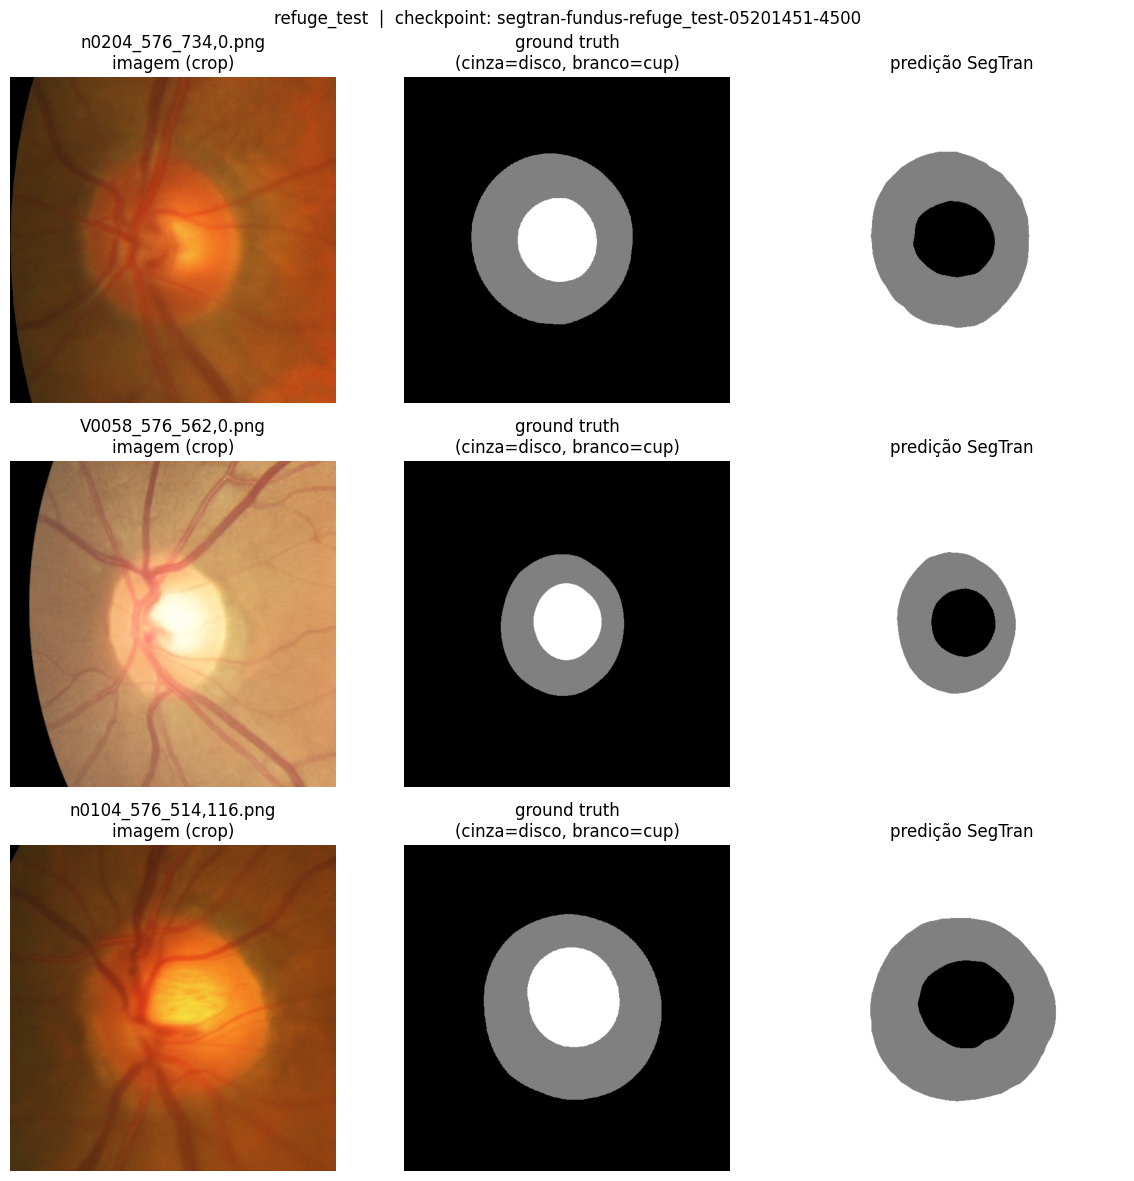

  Predictions from: ./segtran/prediction/segtran-fundus-refuge_test-05201451-4500

--- origa ---


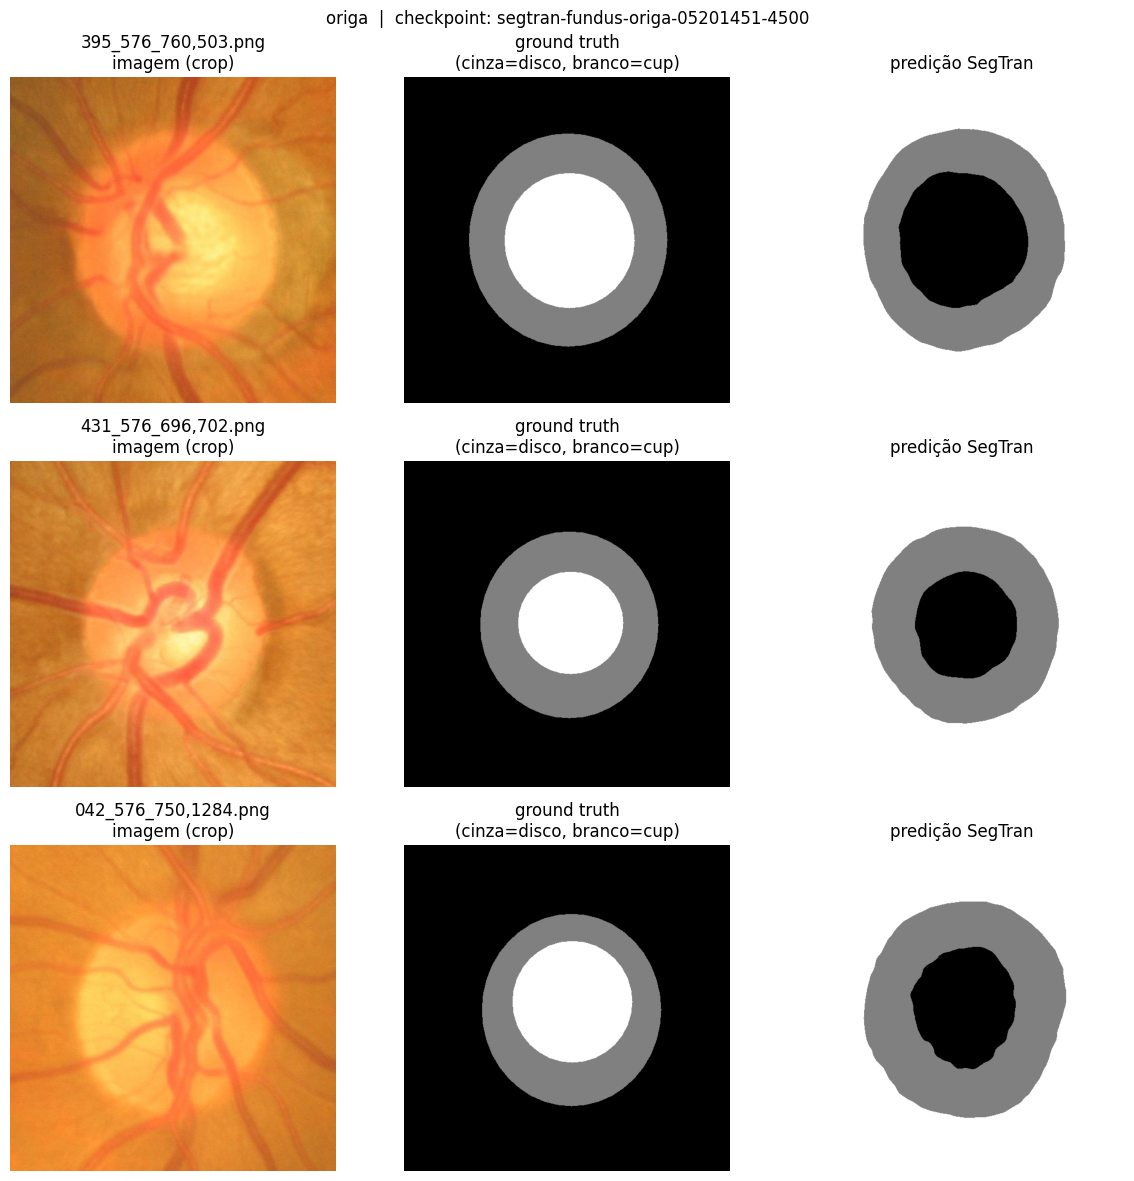

  Predictions from: ./segtran/prediction/segtran-fundus-origa-05201451-4500

--- g1020 ---


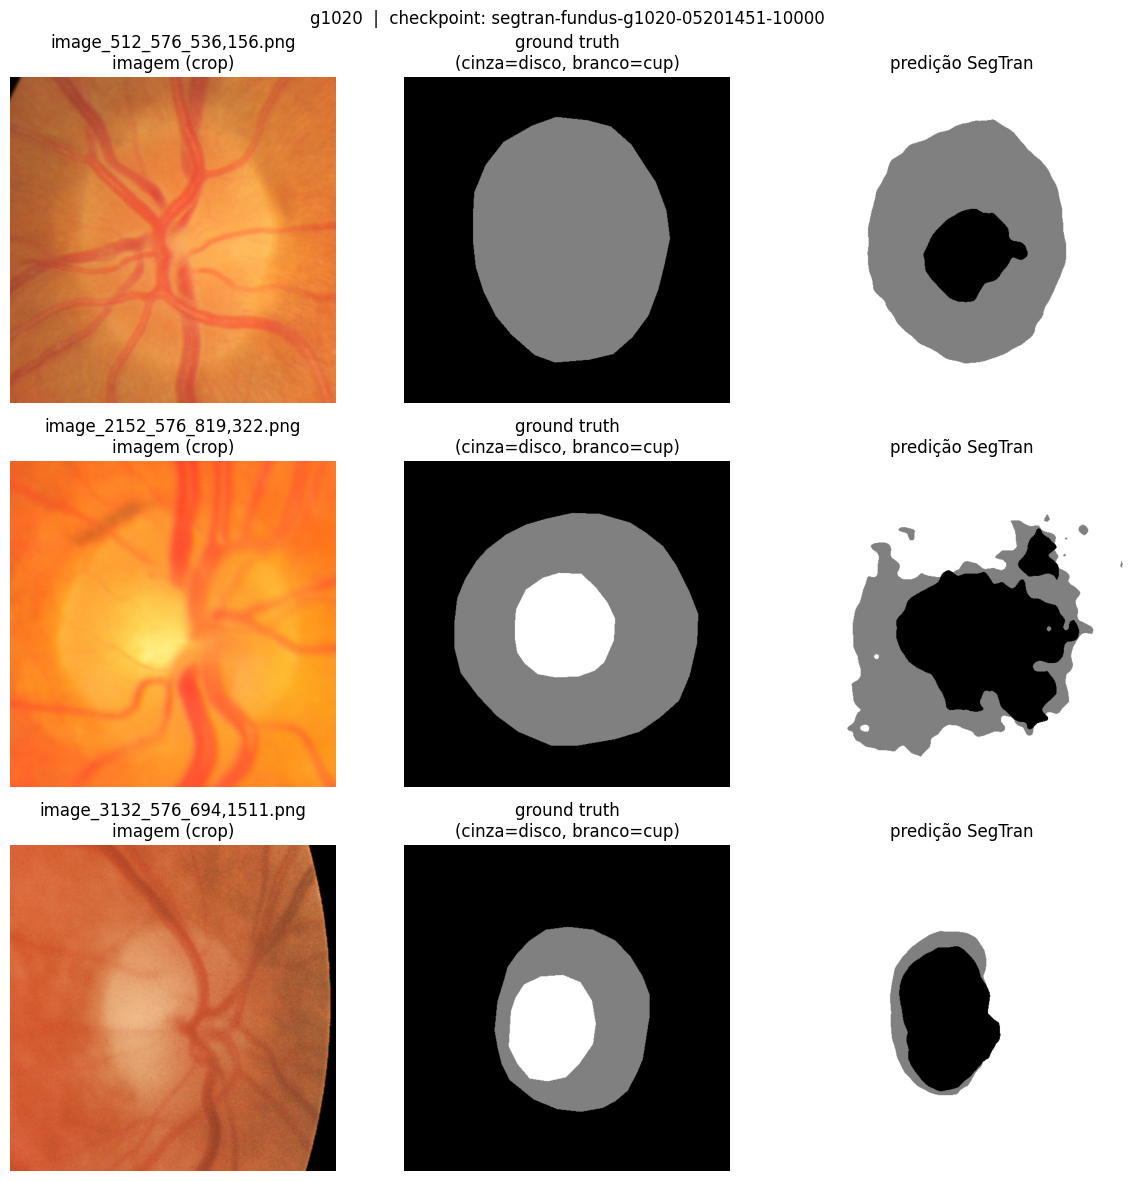

  Predictions from: ./segtran/prediction/segtran-fundus-g1020-05201451-10000


In [15]:
def visualize_predictions(ds_name, n_samples=3):
    """Displays image | GT | prediction for N random samples.

    Predictions are saved by test2d.py in:
      segtran-master/prediction/{net}-fundus-{ds_name}-{timestamp}-{iter}/
    """
    img_dir  = os.path.join(DATA_DIR, ds_name, 'images')
    mask_dir = os.path.join(DATA_DIR, ds_name, 'masks')

    # Find the most recent prediction directory for this dataset
    pred_pattern = os.path.join(PRED_ROOT, f'segtran-fundus-{ds_name}-*')
    pred_dirs    = sorted(
        [d for d in _glob.glob(pred_pattern) if os.path.isdir(d) and '-soft' not in d],
        key=os.path.getmtime
    )

    if not pred_dirs:
        print(f'  [{ds_name}] No predictions found in {PRED_ROOT}')
        return

    pred_dir   = pred_dirs[-1]   # mais recente
    pred_files = sorted(f for f in os.listdir(pred_dir) if f.endswith('.png'))

    if not pred_files:
        print(f'  [{ds_name}] Prediction directory is empty: {pred_dir}')
        return

    import random as _rnd
    _rnd.seed(0)
    samples = _rnd.sample(pred_files, min(n_samples, len(pred_files)))

    fig, axes = plt.subplots(len(samples), 3,
                             figsize=(12, 4 * len(samples)))
    if len(samples) == 1:
        axes = [axes]

    for row, pred_fname in enumerate(samples):
        # Name stem (without extension and crop suffixes)
        stem = pred_fname.split('.')[0]  # e.g. 'g0001'

        # Find image and mask with this prefix
        img_matches  = [f for f in os.listdir(img_dir)
                        if f.startswith(stem) and f.endswith('.png')]
        mask_matches = [f for f in os.listdir(mask_dir)
                        if f.startswith(stem) and f.endswith('.png')]

        # Coluna 0: imagem original (crop)
        if img_matches:
            img = np.array(Image.open(os.path.join(img_dir, img_matches[0])).convert('RGB'))
            axes[row][0].imshow(img)
            axes[row][0].set_title(f'{img_matches[0][:28]}\nimagem (crop)')
        else:
            axes[row][0].set_visible(False)
        axes[row][0].axis('off')

        # Coluna 1: ground truth
        if mask_matches:
            gt = np.array(Image.open(os.path.join(mask_dir, mask_matches[0])))
            if gt.ndim == 3:
                gt_vis = np.zeros(gt.shape[:2], dtype=np.uint8)
                gt_vis[gt[:, :, 0] > 0] = 128   # disco
                gt_vis[gt[:, :, 1] > 0] = 255   # cup
            else:
                gt_vis = gt
            axes[row][1].imshow(gt_vis, cmap='gray', vmin=0, vmax=255)
            axes[row][1].set_title('ground truth\n(cinza=disco, branco=cup)')
        else:
            axes[row][1].set_visible(False)
        axes[row][1].axis('off')

        # Column 2: SegTran prediction
        pred = np.array(Image.open(os.path.join(pred_dir, pred_fname)))
        axes[row][2].imshow(pred, cmap='gray')
        axes[row][2].set_title('SegTran prediction')
        axes[row][2].axis('off')

    plt.suptitle(f'{ds_name}  |  checkpoint: {os.path.basename(pred_dir)}', fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f'  Predictions from: {pred_dir}')


for ds in ['refuge_test', 'origa', 'g1020']:
    print(f'\n--- {ds} ---')
    visualize_predictions(ds, n_samples=3)


## 8. Resumo final

In [16]:
print('=' * 60)
print('PIPELINE SUMMARY — SegTran OPTIC CUP')
print('=' * 60)

print(f'\nTrained checkpoint: {CHECKPOINT_DIR}')
ckpts_final = sorted(_glob.glob(os.path.join(CHECKPOINT_DIR, 'iter_*.pth')))
print(f'Checkpoints saved  : {len(ckpts_final)}')
if ckpts_final:
    print(f'  Last: {os.path.basename(ckpts_final[-1])}')

print('\nPredictions saved in:')
for ds in ['refuge_test', 'origa', 'g1020']:
    pattern = os.path.join(PRED_ROOT, f'segtran-fundus-{ds}-*')
    dirs = sorted(
        [d for d in _glob.glob(pattern) if os.path.isdir(d) and '-soft' not in d],
        key=os.path.getmtime
    )
    if dirs:
        pred_d = dirs[-1]
        n = len([f for f in os.listdir(pred_d) if f.endswith('.png')])
        print(f'  {ds:12s}: {os.path.basename(pred_d)}  ({n} files)')
    else:
        print(f'  {ds:12s}: not found')

print('\nMetrics (Dice):')
for name, log in [('REFUGE test (ID)', test_log),
                  ('ORIGA (OOD)',       origa_log),
                  ('G1020 (OOD)',       g1020_log)]:
    m = extract_dice(log)
    if m:
        print(f'  {name:20s}: disc={m["disc"]:.4f}, cup={m["cup"]:.4f}, avg={m["avg"]:.4f}')
    else:
        print(f'  {name:20s}: (ver log acima)')

print('\n✓ Pipeline completo.')


RESUMO DO PIPELINE SegTran — OPTIC CUP

Checkpoint treinado: /home/bruno-borges/soft_dice_confidence/tasks_models/optic_cup/segtran/model/segtran-fundus-refuge_train-05201451
Checkpoints salvos : 20
  Last: iter_9500.pth

Predictions saved in:
  refuge_test : segtran-fundus-refuge_test-05201451-4500  (240 arquivos)
  origa       : segtran-fundus-origa-05201451-4500  (650 arquivos)
  g1020       : segtran-fundus-g1020-05201451-10000  (1020 arquivos)

Metrics (Dice):
  REFUGE test (ID)    : disc=0.9630, cup=0.8950, avg=0.9290
  ORIGA (OOD)         : disc=0.9260, cup=0.8570, avg=0.8920
  G1020 (OOD)         : disc=0.6370, cup=0.4850, avg=0.5610

✓ Pipeline completo.


## 9. Export — ID/OOD data.npz for uncertainty analysis

In [4]:
# ─── Helpers for extracting predictions and masks ───────────────────────────
import glob as _glob_npz
from PIL import Image as _Image_npz

TARGET_SIZE = 575
OUTPUT_DIR  = os.path.join(os.path.dirname(DATA_DIR), '..', 'data_export')
OUTPUT_DIR  = os.path.normpath(OUTPUT_DIR)
ID_OUT_DIR  = os.path.join(OUTPUT_DIR, 'ID')
OOD_OUT_DIR = os.path.join(OUTPUT_DIR, 'OOD')
os.makedirs(ID_OUT_DIR,  exist_ok=True)
os.makedirs(OOD_OUT_DIR, exist_ok=True)


def find_soft_pred_dir(pred_root, ds_name):
    """Returns the most recent soft prediction directory for ds_name."""
    pattern = os.path.join(pred_root, f'segtran-fundus-{ds_name}-*-soft')
    dirs = sorted(
        [d for d in _glob_npz.glob(pattern) if os.path.isdir(d)],
        key=os.path.getmtime
    )
    if not dirs:
        raise FileNotFoundError(
            f'No soft predictions found for {ds_name} in {pred_root}.\n'
            'Run the inference cells (sections 3-5) first.'
        )
    return dirs[-1]


def build_dataset_arrays(ds_name, soft_pred_dir, mask_root, target_size=TARGET_SIZE):
    """
    Loads soft predictions and cup masks for a dataset.

    soft predictions: PNG (H, W, 3) uint8 — canal 2 = probabilidade cup * 255
    masks:            PNG 3 channels — channel 1 = cup (255 where cup)

    Returns
    -------
    p_hat : (N, 1, target_size, target_size) float32
    y     : (N, 1, target_size, target_size) float32  (binary 0/1)
    """
    pred_files = sorted(f for f in os.listdir(soft_pred_dir) if f.endswith('.png'))

    # Index masks by full stem (without extension), e.g.: 'image_0_576_484,1758'
    # A busca depois usa prefixo para lidar com nomes compostos como 'image_0'.
    mask_index = {}
    for fname in sorted(os.listdir(mask_root)):
        if not fname.endswith('.png'):
            continue
        full_stem = fname[:-4]
        mask_index[full_stem] = fname

    p_hats, ys = [], []
    skipped_no_mask = skipped_empty = 0

    for pred_fname in pred_files:
        stem = pred_fname[:-4]   # ex: 'image_0', 'g0002', '001'

        # ── soft prediction: channel 2 = cup probability ────────────────────────
        pred_np  = np.array(_Image_npz.open(os.path.join(soft_pred_dir, pred_fname)))
        cup_prob = pred_np[:, :, 2].astype(np.float32) / 255.0

        # ── locate mask: exact stem or stem as prefix + '_' ──────────
        mask_fname = next(
            (v for k, v in mask_index.items()
             if k == stem or k.startswith(stem + '_')),
            None
        )
        if mask_fname is None:
            skipped_no_mask += 1
            continue

        mask_np = np.array(_Image_npz.open(os.path.join(mask_root, mask_fname)))
        if mask_np.ndim == 3:
            cup_mask = (mask_np[:, :, 1] > 0).astype(np.float32)
        else:
            cup_mask = (mask_np == 0).astype(np.float32)

        # ── filter empty mask (pre-resize) ────────────────────────────────
        if cup_mask.sum() == 0:
            skipped_empty += 1
            continue

        # ── resize to target_size × target_size ───────────────────────
        cup_prob_r = np.array(
            _Image_npz.fromarray((cup_prob * 255).astype(np.uint8))
                      .resize((target_size, target_size), _Image_npz.BILINEAR),
            dtype=np.float32
        ) / 255.0

        cup_mask_r = (np.array(
            _Image_npz.fromarray((cup_mask * 255).astype(np.uint8))
                      .resize((target_size, target_size), _Image_npz.NEAREST),
            dtype=np.float32
        ) > 127).astype(np.float32)

        # ── filter empty mask (post-resize) ────────────────────────────────
        if cup_mask_r.sum() == 0:
            skipped_empty += 1
            continue

        p_hats.append(cup_prob_r[np.newaxis])
        ys.append(cup_mask_r[np.newaxis])

    print(f'  {ds_name}: {len(p_hats)} valid samples | '
          f'no mask: {skipped_no_mask} | empty mask: {skipped_empty}')

    return np.stack(p_hats), np.stack(ys)


print(f'Output dir : {OUTPUT_DIR}')
print(f'TARGET_SIZE: {TARGET_SIZE}x{TARGET_SIZE}')
print('Helpers definidos.')

Output dir : segtran/data_export
TARGET_SIZE: 575x575
Helpers definidos.


In [5]:
# ─── Save ID/data.npz (REFUGE test) ─────────────────────────────────────────
print('=== ID — REFUGE test ===')
soft_dir_id = find_soft_pred_dir(PRED_ROOT, 'refuge_test')
print(f'  Soft preds: {soft_dir_id}')

p_hat_id, y_id = build_dataset_arrays(
    'refuge_test',
    soft_dir_id,
    os.path.join(DATA_DIR, 'refuge_test', 'masks'),
)

np.savez_compressed(os.path.join(ID_OUT_DIR, 'data.npz'), p_hat=p_hat_id, y=y_id)
print(f'  Saved: {ID_OUT_DIR}/data.npz')
print(f'  p_hat: {p_hat_id.shape}  y: {y_id.shape}')

# ─── Save OOD/data.npz (ORIGA + G1020) ──────────────────────────────────────
print()
print('=== OOD — ORIGA + G1020 ===')

p_hats_ood, ys_ood = [], []
for ds in ['origa', 'g1020']:
    soft_dir_ood = find_soft_pred_dir(PRED_ROOT, ds)
    print(f'  [{ds}] Soft preds: {soft_dir_ood}')
    ph, y_ = build_dataset_arrays(
        ds,
        soft_dir_ood,
        os.path.join(DATA_DIR, ds, 'masks'),
    )
    p_hats_ood.append(ph)
    ys_ood.append(y_)

p_hat_ood = np.concatenate(p_hats_ood, axis=0)
y_ood     = np.concatenate(ys_ood,     axis=0)

np.savez_compressed(os.path.join(OOD_OUT_DIR, 'data.npz'), p_hat=p_hat_ood, y=y_ood)
print(f'  Saved: {OOD_OUT_DIR}/data.npz')
print(f'  p_hat: {p_hat_ood.shape}  y: {y_ood.shape}')

# ─── Final verification ────────────────────────────────────────────────────────
print()
print('=== Verification ===')
for split, out_dir in [('ID', ID_OUT_DIR), ('OOD', OOD_OUT_DIR)]:
    d  = np.load(os.path.join(out_dir, 'data.npz'))
    ph, y = d['p_hat'], d['y']

    assert ph.ndim == 4 and ph.shape[1:] == (1, TARGET_SIZE, TARGET_SIZE), \
        f'{split} p_hat shape errado: {ph.shape}'
    assert y.shape == ph.shape, \
        f'{split} y shape does not match p_hat: {y.shape} vs {ph.shape}'

    mask_sums = y.sum(axis=(1, 2, 3))
    assert (mask_sums > 0).all(), \
        f'{split}: {(mask_sums == 0).sum()} empty masks found!'

    print(f'  {split}: p_hat={ph.shape}  y={y.shape}  '
          f'min_mask_sum={mask_sums.min():.0f}  ✓')

print()
print('✓ Export complete.')


=== ID — REFUGE test ===
  Soft preds: ./segtran/prediction/segtran-fundus-refuge_test-05201451-4500-soft
  refuge_test: 240 valid samples | no mask: 0 | empty mask: 0
  Salvo: segtran/data_export/ID/data.npz
  p_hat: (240, 1, 575, 575)  y: (240, 1, 575, 575)

=== OOD — ORIGA + G1020 ===
  [origa] Soft preds: ./segtran/prediction/segtran-fundus-origa-05201451-4500-soft
  origa: 650 valid samples | no mask: 0 | empty mask: 0
  [g1020] Soft preds: ./segtran/prediction/segtran-fundus-g1020-05201451-10000-soft
  g1020: 788 valid samples | no mask: 0 | empty mask: 232
  Salvo: segtran/data_export/OOD/data.npz
  p_hat: (1438, 1, 575, 575)  y: (1438, 1, 575, 575)

=== Verification ===
  ID: p_hat=(240, 1, 575, 575)  y=(240, 1, 575, 575)  min_mask_sum=3627  ✓
  OOD: p_hat=(1438, 1, 575, 575)  y=(1438, 1, 575, 575)  min_mask_sum=3742  ✓

✓ Export complete.
